In [3]:
import pandas as pd
data=pd.read_csv("data/cardio_train.csv", sep=";")


In [4]:
print(data.head())
print(data.shape)
print(data.info())

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
(70000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null

In [8]:
print(data.columns.tolist())

['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


In [5]:
# Check missing values
print(data.isnull().sum())
# Check zero values in each column
print((data == 0).sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
id                 1
age                0
gender             0
height             0
weight             0
ap_hi              0
ap_lo             21
cholesterol        0
gluc               0
smoke          63831
alco           66236
active         13739
cardio         35021
dtype: int64


In [6]:
# Remove duplicates values from the dataset
print("Before removing duplicates:", data.shape)
data = data.drop_duplicates()
print("After removing duplicates:", data.shape)

Before removing duplicates: (70000, 13)
After removing duplicates: (70000, 13)


In [10]:
import numpy as np
# Columns where 0 represents an invalid/missing measurement
columns = ['height', 'weight', 'ap_hi', 'ap_lo']

# Replace 0 with NaN
data[columns] = data[columns].replace(0, np.nan)

# Check missing values
print(data.isnull().sum())

id              0
age             0
gender          0
height          0
weight          0
ap_hi           0
ap_lo          21
cholesterol     0
gluc            0
smoke           0
alco            0
active          0
cardio          0
dtype: int64


In [11]:
# Fill misssing values with median of each column
for column in columns:
    data[column] = data[column].fillna(data[column].median())

print(data.isnull().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [12]:
# Verify the changes by checking the first 5 rows of the dataset again
print(data.head())

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110   80.0            1     1      0   
1   1  20228       1     156    85.0    140   90.0            3     1      0   
2   2  18857       1     165    64.0    130   70.0            3     1      0   
3   3  17623       2     169    82.0    150  100.0            1     1      0   
4   4  17474       1     156    56.0    100   60.0            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  


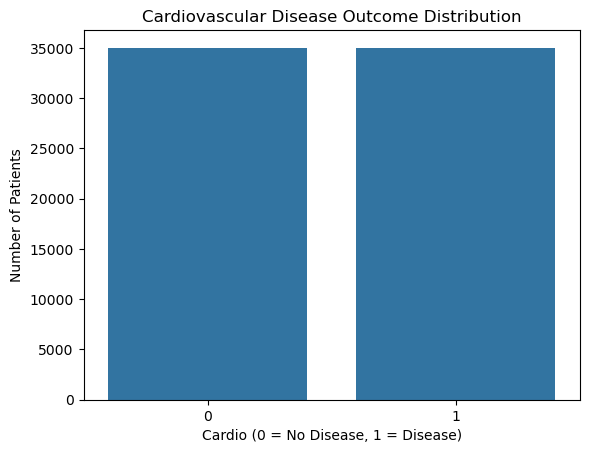

In [14]:
# Visualize the distribution of the target variable 'cardio'

import matplotlib.pyplot as plt
import seaborn as sns

# Count of cardiovascular disease outcomes
sns.countplot(x='cardio', data=data)

plt.title('Cardiovascular Disease Outcome Distribution')
plt.xlabel('Cardio (0 = No Disease, 1 = Disease)')
plt.ylabel('Number of Patients')
plt.show()

In [16]:
# Separate features and target
X = data.drop('cardio', axis=1)  # Take all columns except cardio as input
y = data['cardio']               # Take cardio column as target

# Display the first 5 rows of features
print("Features:")
print(X.head())

# Display the first 5 rows of target
print("\nTarget:")
print(y.head())

Features:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110   80.0            1     1      0   
1   1  20228       1     156    85.0    140   90.0            3     1      0   
2   2  18857       1     165    64.0    130   70.0            3     1      0   
3   3  17623       2     169    82.0    150  100.0            1     1      0   
4   4  17474       1     156    56.0    100   60.0            1     1      0   

   alco  active  
0     0       1  
1     0       1  
2     0       0  
3     0       1  
4     0       0  

Target:
0    0
1    1
2    1
3    1
4    0
Name: cardio, dtype: int64


In [17]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape) # (614, 8)
print("Testing data:", X_test.shape)

Training data: (56000, 12)
Testing data: (14000, 12)


In [18]:
# Create a new notebook cell:
from sklearn.linear_model import LogisticRegression

In [19]:
# Create a Logistic Regression model with a maximum of 1000 iterations to ensure convergence.
model = LogisticRegression(max_iter=1000)

In [20]:
# Train the model using the training data
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
# Make predictions on the testing set
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 ... 0 1 1]


In [22]:
from sklearn.metrics import accuracy_score
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy in percentage:", accuracy * 100, "%")

Accuracy: 0.7128571428571429
Accuracy in percentage: 71.28571428571429 %


In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate a confusion matrix to visualize the performance of the model
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5239 1749]
 [2271 4741]]


In [24]:
# joblib is a library for efficiently serializing and deserializing Python objects, which is particularly useful for saving machine learning models. In this case, we will use joblib to save the trained Logistic Regression model to a file so that it can be loaded and used later without needing to retrain it.
import joblib

In [25]:
# Save the trained model to a file using joblib
joblib.dump(model, 'model/diabetes_model.pkl')
print("Model saved successfully!")

Model saved successfully!
